In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../Dataset/loan.csv')
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


# OutLiers

## Box plot visulisation

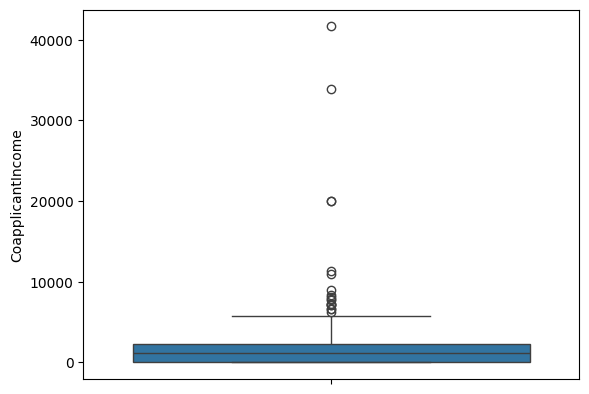

In [3]:
sns.boxplot(df.CoapplicantIncome)
plt.show()

### Remove Outlier using IQR

In [4]:
Q1 = df["CoapplicantIncome"].quantile(0.25)
Q3 = df["CoapplicantIncome"].quantile(0.75)

In [5]:
IQR = Q3 - Q1

In [6]:
min_range = Q1 - (1.5 * IQR)
max_range = Q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-3445.875
5743.125


In [7]:
without_otl = df[df['CoapplicantIncome'] <= max_range]

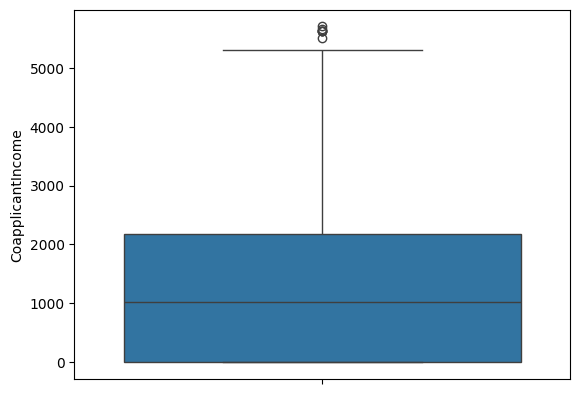

In [8]:
sns.boxplot(without_otl.CoapplicantIncome)
plt.show()

### Remove Outlier using Z-score

### μ = Mean
### σ = Standard Deviation

## $$
z = \frac{x - \mu}{\sigma}
$$

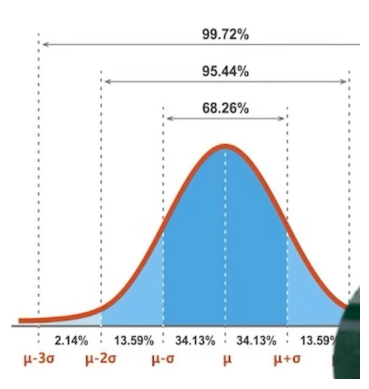

In [9]:
# using direct method
import matplotlib.image as mpimg

# read and display image
img = mpimg.imread('../Image/z-score.png')
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()

<Axes: ylabel='ApplicantIncome'>

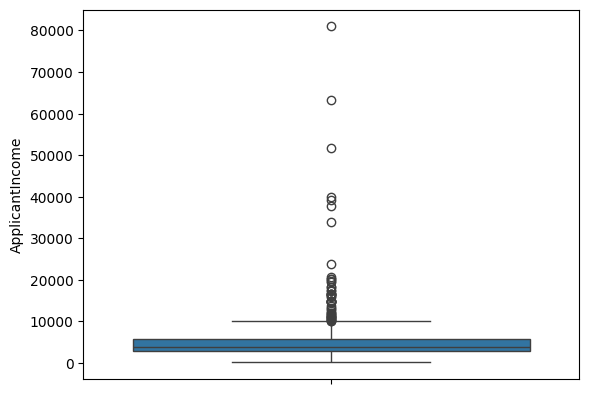

In [10]:
sns.boxplot(without_otl.ApplicantIncome)

In [11]:
# we are use this 3σ for 99.72% range of our data
min_range = df['ApplicantIncome'].mean() - (3 * df['ApplicantIncome'].std())
max_range = df['ApplicantIncome'].mean() + (3 * df['ApplicantIncome'].std())

min_range, max_range

(np.float64(-12923.66573677391), np.float64(23730.584303549156))

In [12]:
new_data = df[df['ApplicantIncome'] <= max_range]

<Axes: ylabel='ApplicantIncome'>

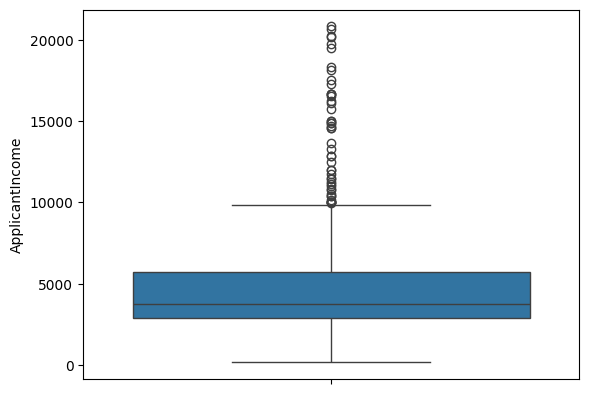

In [13]:
# Now that outliers are not harmfull for us
sns.boxplot(new_data['ApplicantIncome'])

In [14]:
# now we are doing with z-score

In [15]:
z_score = (df['CoapplicantIncome'] - df['CoapplicantIncome'].mean())/df['CoapplicantIncome'].std()
z_score

0     -0.554036
1     -0.038700
2     -0.554036
3      0.251774
4     -0.554036
         ...   
609   -0.554036
610   -0.554036
611   -0.472019
612   -0.554036
613   -0.554036
Name: CoapplicantIncome, Length: 614, dtype: float64

In [16]:
df['z_score'] = z_score